# Notebook to test and see the implementation of Hierarchical Refinement algorithm in jax

In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn_lr

from src.HiRef import hierarchical_refinement_iterative
from src.partition import low_rank_partition
from src.rank_annealing import optimal_rank_schedule

In [2]:
rank_schedule = optimal_rank_schedule(n=1000000, hierarchy_depth=6, max_Q=100, max_rank=10)

Optimized rank-annealing schedule: [5, 5, 5, 10, 10, 80]


In [3]:
def create_points(
    rng= jax.random.key(0),       # seed for randomeness
    n: int = 100,       # number of points for X and Y
    d: int = 2,         # dimension vectors in X and Y
    ):
    """
    By default we use uniform distribution for a and b.
    """
    rngs = jax.random.split(rng, 4)
    x = jax.random.normal(rngs[0], (n, d)) + 10
    y = jax.random.normal(rngs[1], (n, d))
    a = jax.random.uniform(rngs[2], (n,))
    b = jax.random.uniform(rngs[3], (n,))
    a = a / jnp.sum(a)
    b = b / jnp.sum(b)
    return x, y, a, b

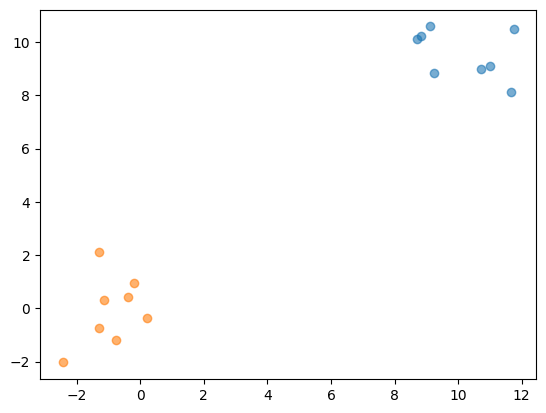

In [4]:
x, y, a, b = create_points( n=8, d=2)

c_src1 = "#1f77b4"   # bleu foncé
c_tgt1 = "#aec7e8"   # bleu clair

c_src2 = "#ff7f0e"   # orange foncé
c_tgt2 = "#ffbb78"   # orange clair


plt.scatter(x[:, 0], x[:, 1], color=c_src1, label="Source_1", alpha=0.6)
plt.scatter(y[:, 0], y[:, 1], color=c_src2, label="Source_2", alpha=0.6)

#plt.scatter(y1[:, 0], y1[:, 1], color=c_tgt1, label="Target_1", alpha=0.6)
#plt.scatter(y2[:, 0], y2[:, 1], color=c_tgt2, label="Target_2", alpha=0.6)

plt.show()

In [5]:
clusters = hierarchical_refinement_iterative(X=x, Y=y, strategy="rank_annealing")

Optimized rank-annealing schedule: [8]
Optimized rank-annealing schedule: [8]
Stack size: 1

[Depth 0] Processing block of size 8 with rank 8


AttributeError: 'LRSinkhornOutput' object has no attribute 'projection_x'

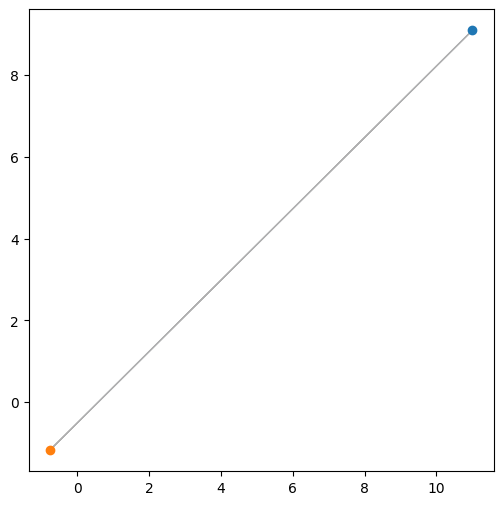

In [72]:
plt.figure(figsize=(6,6))
for pair in clusters:
    x, y, d, _ = pair
    plt.arrow(x[0][0], x[0][1],
            y[0][0] - x[0][0],
            y[0][1] - x[0][1],
            head_width=0.05, alpha=0.3, length_includes_head=True)
    plt.scatter(x[0,0], x[0,1], c='C0', label='Source')
    plt.scatter(y[0,0], y[0,1], c='C1', label='Target')

plt.show()